In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/insurance.csv")

In [3]:
df.head()
df.shape
df.columns
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [7]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [8]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

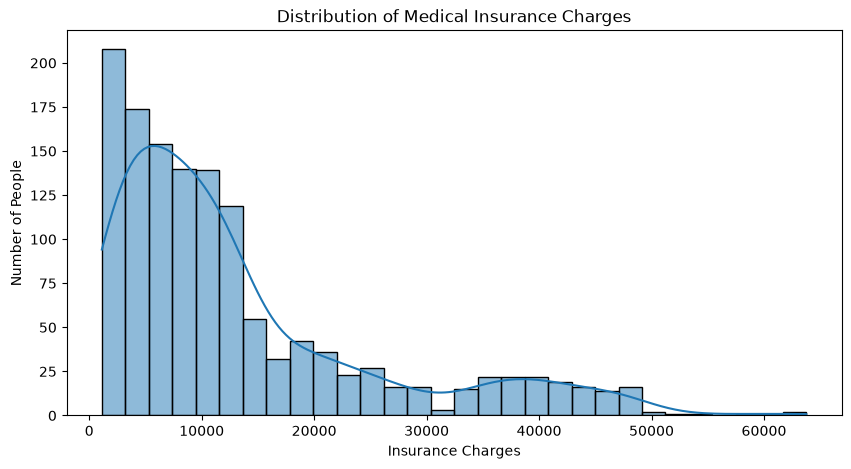

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(df["charges"], bins=30, kde=True)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Number of People")

plt.show()

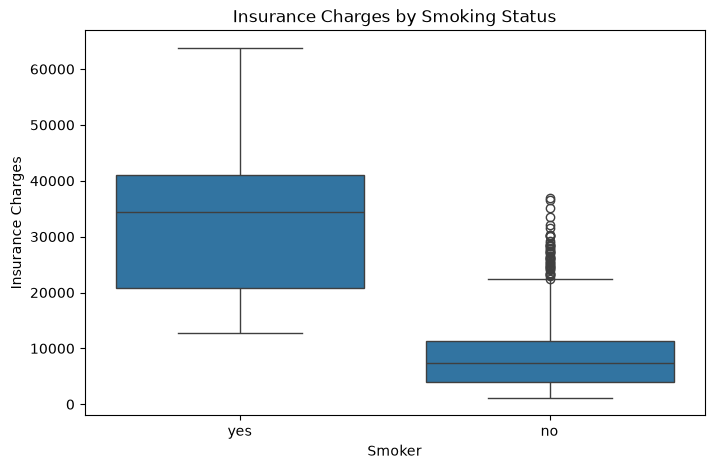

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Insurance Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.show()

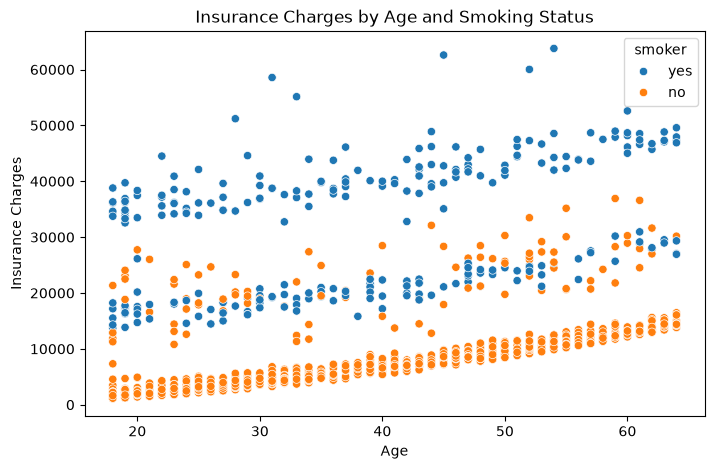

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="age",
    y="charges",
    data=df,
    hue="smoker"
)

plt.title("Insurance Charges by Age and Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

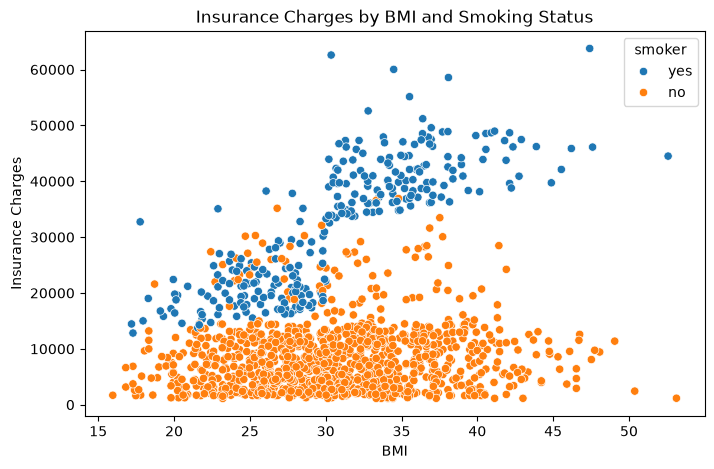

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="bmi",
    y="charges",
    data=df,
    hue="smoker"
)

plt.title("Insurance Charges by BMI and Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

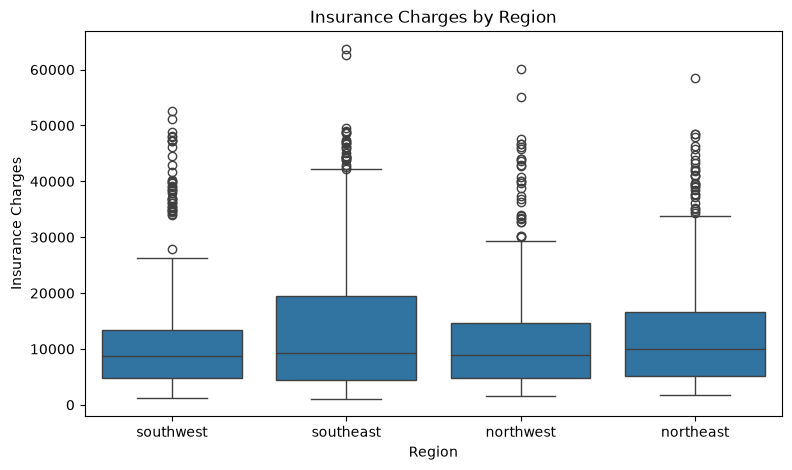

In [13]:
plt.figure(figsize=(9, 5))

sns.boxplot(x="region", y="charges", data=df)

plt.title("Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Insurance Charges")

plt.show()

In [14]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [15]:
df.groupby("region")["charges"].mean()

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

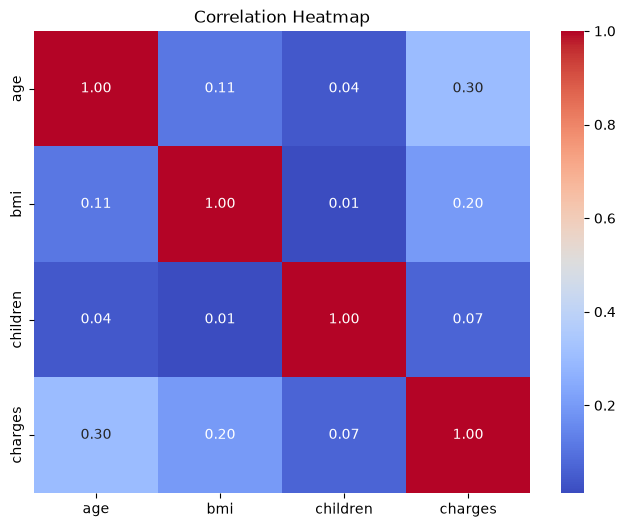

In [16]:
# Select numerical columns
numerical_df = df.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()